In [7]:
import numpy as np
import cv2
import requests
import sys
from os import path
import matplotlib.pyplot as plt

In [8]:
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.figsize'] = (15.0,15.0)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 14

In [9]:
objectnessThreshold = 0.5
confThreshold = 0.5
nmsThreshold = 0.4
inpWidth = 416
inpHeight = 416

In [10]:
classesFile = '../coco.names'
classes = None
with open(classesFile,'rt') as f:
    classes = f.read().rstrip('\n').split('\n')

modelConfiguration = "../yolov4.cfg"
modelWeights = "yolov4.weights"

if (not path.exists(modelWeights)):
    url = "https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights"
    r = requests.get(url)
    print("Downloading YOLO v4 Model")
    with open(modelWeights,'wb') as f:
        f.write(r.content)

    print('\n yolov4.weights Download complete ')


 yolov4.weights Download complete 


In [11]:
net = cv2.dnn.readNetFromDarknet(modelConfiguration,modelWeights)

In [12]:
def getOutputsNames(net):
    layersNames = net.getLayerNames()
    return [layersNames[i-1] for i in net.getUnconnectedOutLayers()]

In [26]:
FONTFACE = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.7
THICKNESS = 1

def display_objects(frame, outs):
    frameHeight = frame.shape[0]
    frameWidth = frame.shape[1]

    classIds = []
    confidences = []
    boxes = []

    for out in outs:
        for detection in out:
            if detection[4] > objectnessThreshold:
                scores = detection[5:]
                classId = np.argmax(scores)
                confidence = scores[classId]
                if confidence > confThreshold:
                    center_x = int(detection[0] * frameWidth)
                    center_y = int(detection[1] * frameHeight)
                    width = int(detection[2] * frameWidth)
                    height = int(detection[3] * frameHeight)

                    left = int(center_x - width / 2)
                    top = int(center_y - height / 2)
                    classIds.append(classId)
                    confidences.append(float(confidence))
                    boxes.append([left, top, width, height])

    indices = cv2.dnn.NMSBoxes(boxes, confidences, confThreshold, nmsThreshold)
    for i in indices:
        box = boxes[i]
        left = box[0]
        top = box[1]
        width = box[2]
        height = box[3]
        cv2.rectangle(frame, (left, top),(left + width, top + height), (255,255,255), 2)
        label = '{}:{:.2f}'.format(classes[classIds[i]],confidences[i])
        display_text(frame, label, left, top)
                                   

In [29]:
def display_text(im, text, x, y):
    textSize = cv2.getTextSize(text, FONTFACE, FONT_SCALE, THICKNESS)
    dim = textSize[0]
    baseline = textSize[1]

    cv2.rectangle (im, (x,y), (x + dim[0], y + dim[1] + baseline),(0,0,0), cv2.FILLED)
    cv2.putText(im, text, (x, y + dim[1]), FONTFACE, FONT_SCALE, (0,255,255), THICKNESS, cv2.LINE_AA)

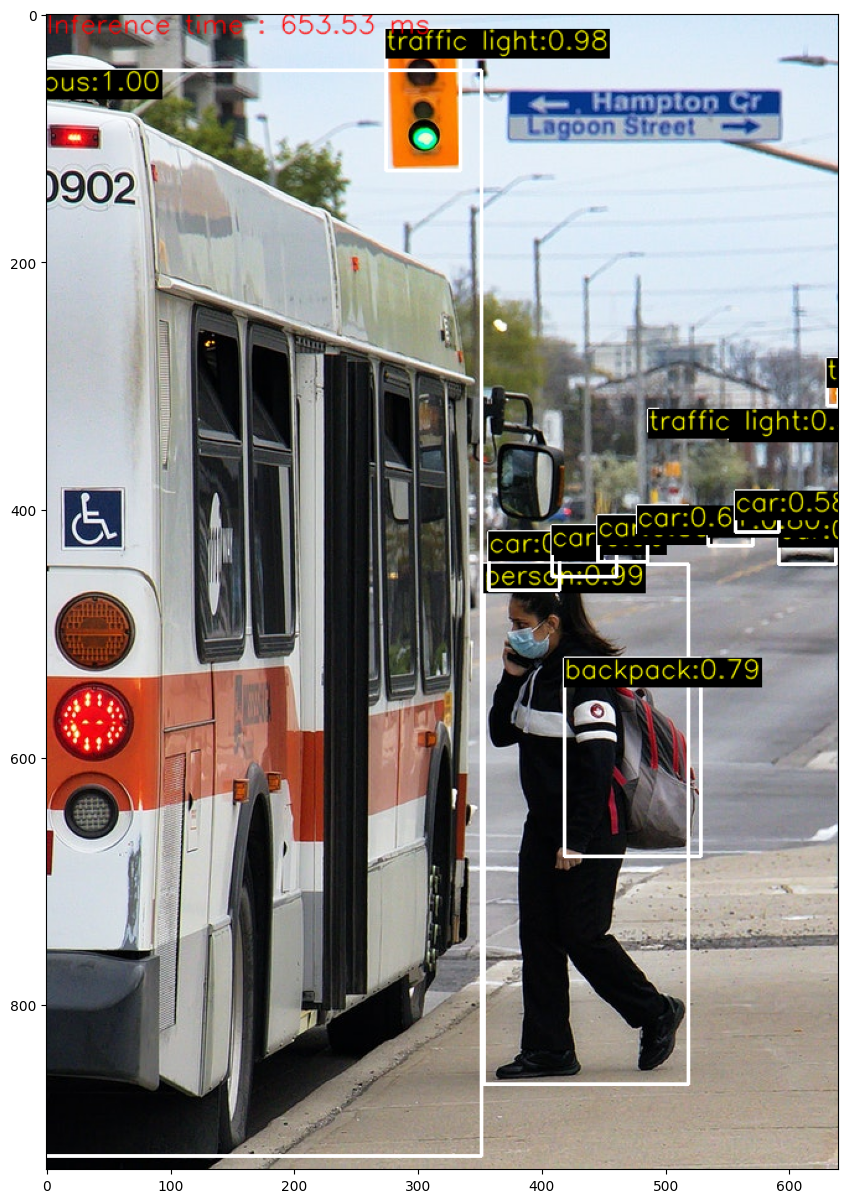

Inference time : 653.53 ms


In [30]:
image_path = "../traffic.jpg"
frame = cv2.imread(image_path)

blob = cv2.dnn.blobFromImage(frame, 1/255, (inpWidth, inpHeight), [0,0,0], 1, crop = False)

net.setInput(blob)

outs = net.forward(getOutputsNames(net))

display_objects(frame, outs)

t, _ = net.getPerfProfile()
label = 'Inference time : %.2f ms' %(t * 1000.0 / cv2.getTickFrequency())
cv2.putText(frame, label, (0,15), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 1 , cv2.LINE_AA)

plt.imshow(frame[:,:,::-1])

plt.show()

print(label)             

In [32]:
tiny_modelConfiguration = "../yolov4-tiny.cfg"
tiny_modelWeights = 'yolov4-tiny.weights'

if (not path.exists(tiny_modelWeights)):
    url = 'https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.weights'
    r = requests.get(url)

    with open(tiny_modelWeights,'wb') as f:
        f.write(r.content)
    print("Downlaod Complete")
net_tiny = cv2.dnn.readNetFromDarknet(tiny_modelConfiguration, tiny_modelWeights)
    

In [ ]:
imagePath = '../traffic.jpg'
frame = cv2.imread(imagePath)

blob = cv2.dnn.blobFromImage(frame, 1/255, (inpWidth, inpHeight),[0,0,0], crop = False)

net_tiny.setInput(blob)

outs = net_tiny.forward(getOutputsNames(net_tiny))

display_objects(frame, outs)

t, _ = net_tiny.getPerfProfiles()

label = "Inference time : %.2f ms".format(t * 1000.0 / cv2.getTickFrequency())
cv2.putText(frame, label, (0,15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255))

plt.imshow(frame[..., ::-1])
plt.